In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.append("../..")

from src.classifical_features import build_monthly_features
from src.configs.settings import Settings
from src.visualization.visualization import (
    plot_best_predictions,
    plot_overall_metrics_comparison,
    plot_panel_metrics_distributions,
    plot_worst_predictions,
)

settings = Settings()

In [2]:
data_dir = Path("../../data")

In [3]:
features_df = pd.read_csv(data_dir / "processed" / "mirrors_clusters.csv")
mirrors_ts_df = pd.read_csv(data_dir / "processed" / "filtered_mirrors_ts.csv")

In [4]:
features = build_monthly_features(mirrors_ts_df, settings)
features["panel_id"] = features[settings.columns.id].astype(str)

Processing panels: 100%|██████████| 1511/1511 [00:04<00:00, 306.69it/s]


In [5]:
from src.catboost_utilities.evaluate import evaluate_catboost
from src.catboost_utilities.train import train_catboost
from src.custom_types import CatBoostParameters
from src.model_selection import temporal_panel_split_by_date

regression_splits = temporal_panel_split_by_date(
    features,
    panel_column=settings.columns.id,
    time_column=settings.columns.date,
    train_range=settings.split.train,
    val_range=settings.split.val,
    test_range=settings.split.test,
)

In [6]:
from src.data_processing import scale_panel_splits

scale = not settings.downstream.round_predictions
if scale:
    splits = scale_panel_splits(
        (data for _, data in regression_splits.splits),
        panel_column=settings.columns.id,
        target_columns=settings.columns.main_target,
        apply_log=settings.preprocessing.apply_log,
    )
else:
    splits = regression_splits

In [7]:
catboost_params = CatBoostParameters(
    iterations=500,
    learning_rate=0.05,
    depth=3,
    l2_leaf_reg=10,
    subsample=0.8,
    rsm=0.8,
    random_seed=settings.random_state,
    verbose=50,
    loss_function="RMSE",
)

catboost_model = train_catboost(
    train_df=splits.train,
    val_df=splits.val,
    params=catboost_params,
    settings=settings,
)

results = evaluate_catboost(
    model=catboost_model,
    splits=splits,
    settings=settings,
    scalers=None,
)

0:	learn: 79.5584626	total: 46.6ms	remaining: 23.2s
50:	learn: 62.5542097	total: 80.2ms	remaining: 706ms
100:	learn: 57.6452248	total: 111ms	remaining: 440ms
150:	learn: 55.7926977	total: 144ms	remaining: 332ms
200:	learn: 54.5968768	total: 178ms	remaining: 265ms
250:	learn: 53.8480961	total: 212ms	remaining: 210ms
300:	learn: 53.0310590	total: 254ms	remaining: 168ms
350:	learn: 51.9932979	total: 290ms	remaining: 123ms
400:	learn: 50.9005272	total: 323ms	remaining: 79.7ms
450:	learn: 49.9996012	total: 357ms	remaining: 38.8ms
499:	learn: 49.1148819	total: 390ms	remaining: 0us


Evaluating test panels:   0%|          | 0/1233 [00:00<?, ?it/s]/home/nikita/projects/microniches/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/nikita/projects/microniches/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/nikita/projects/microniches/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/nikita/projects/microniches/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/hom

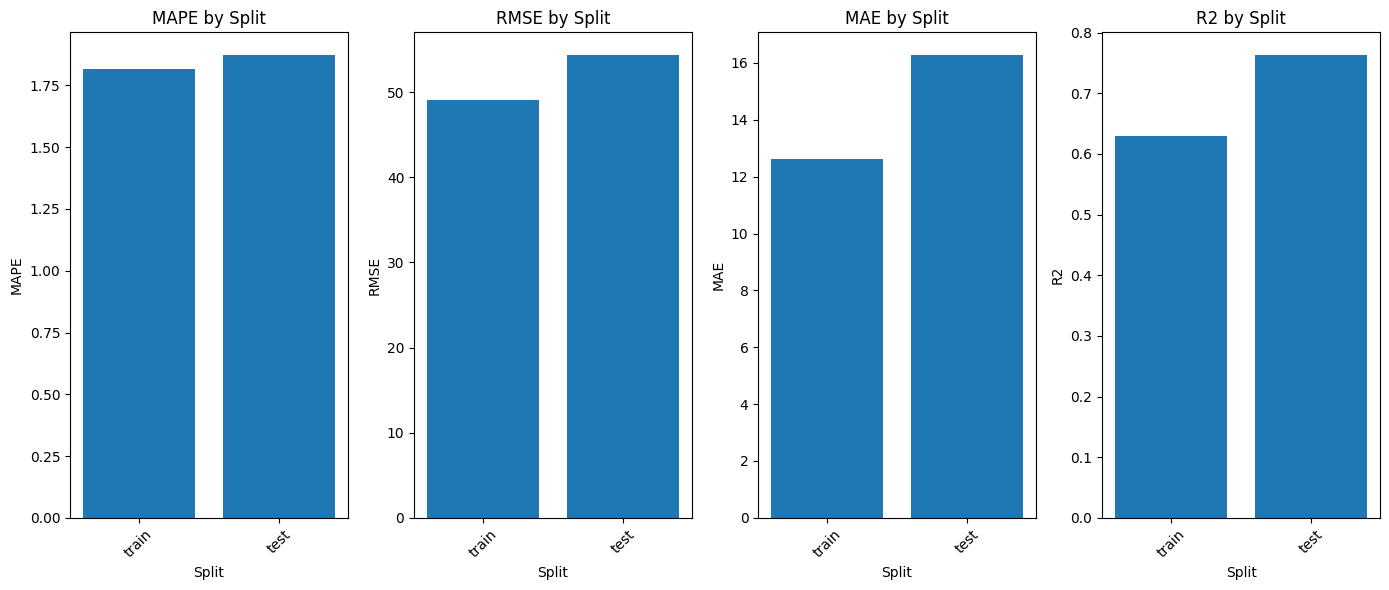

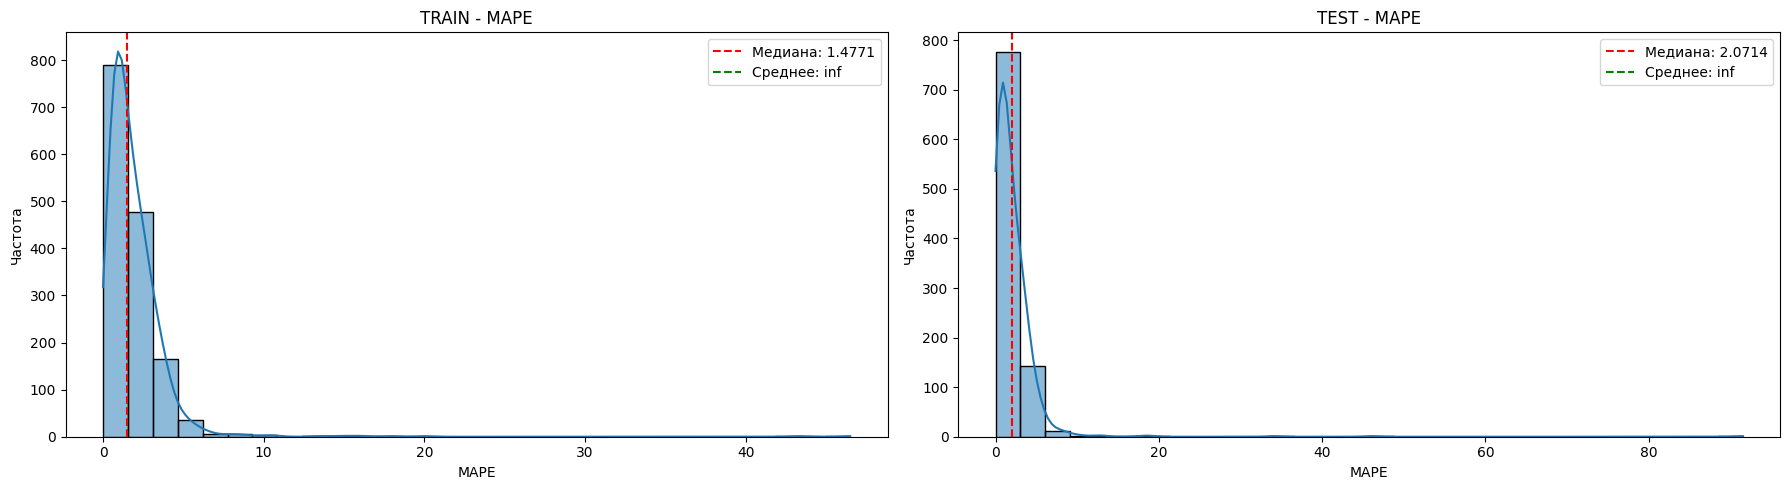

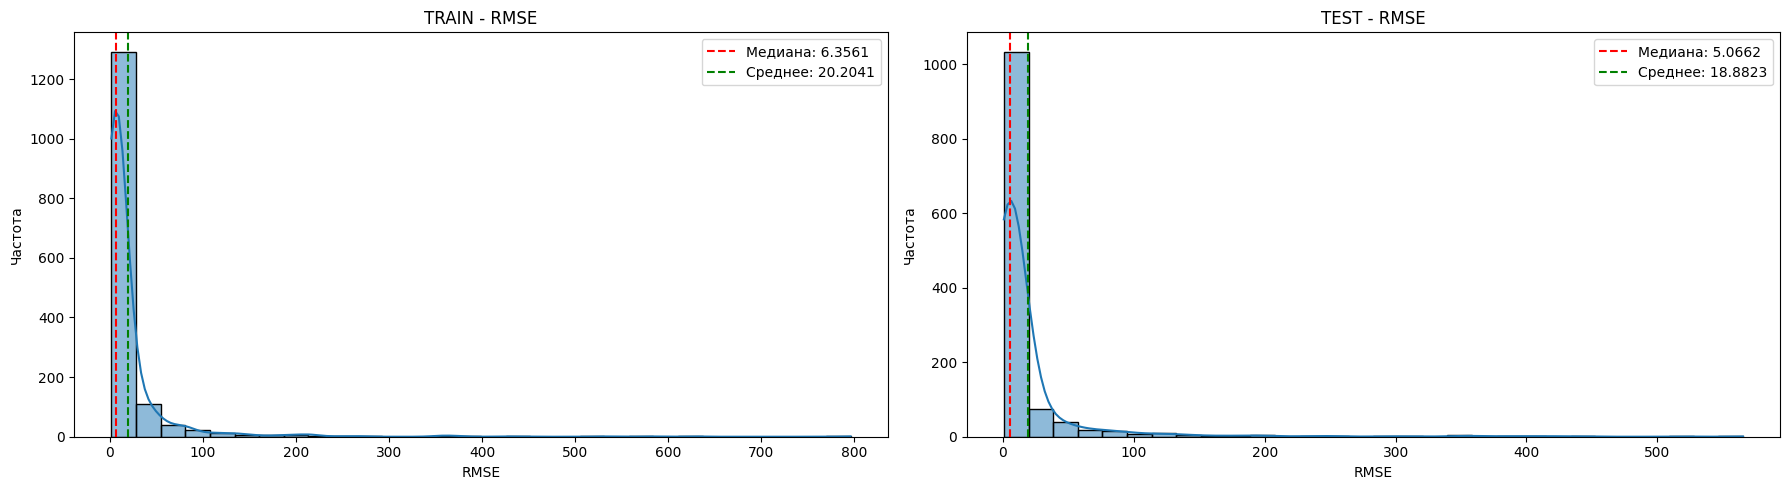

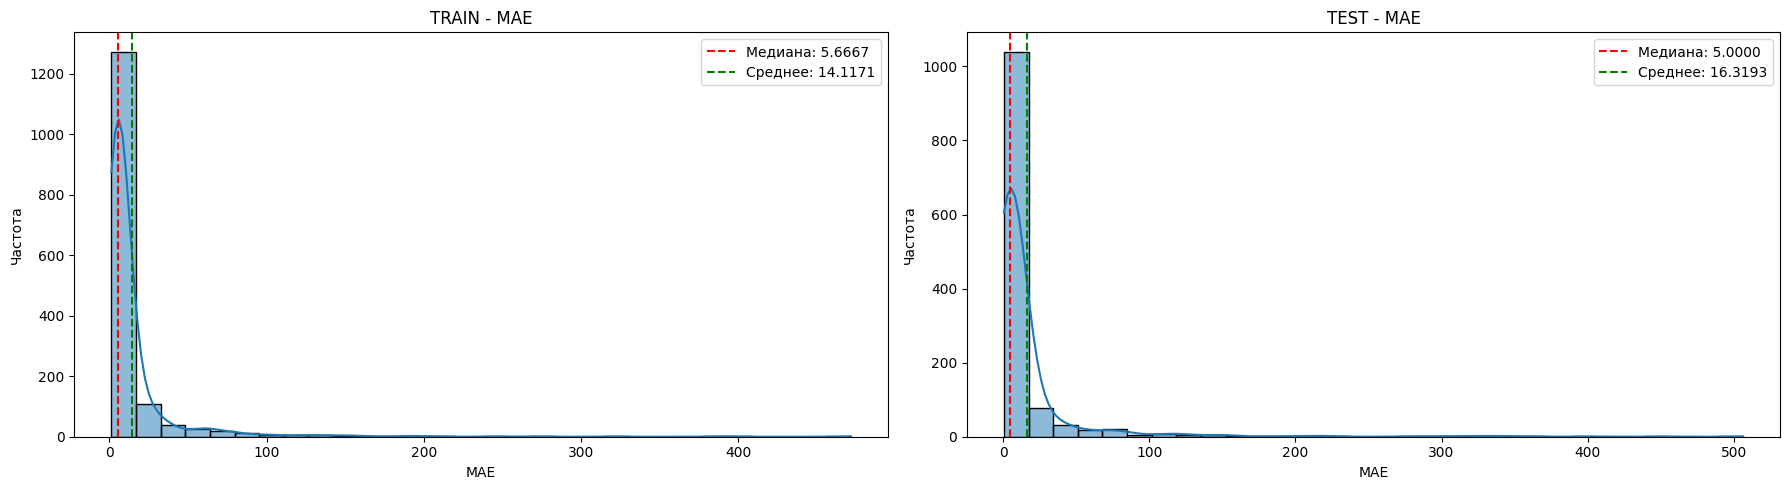

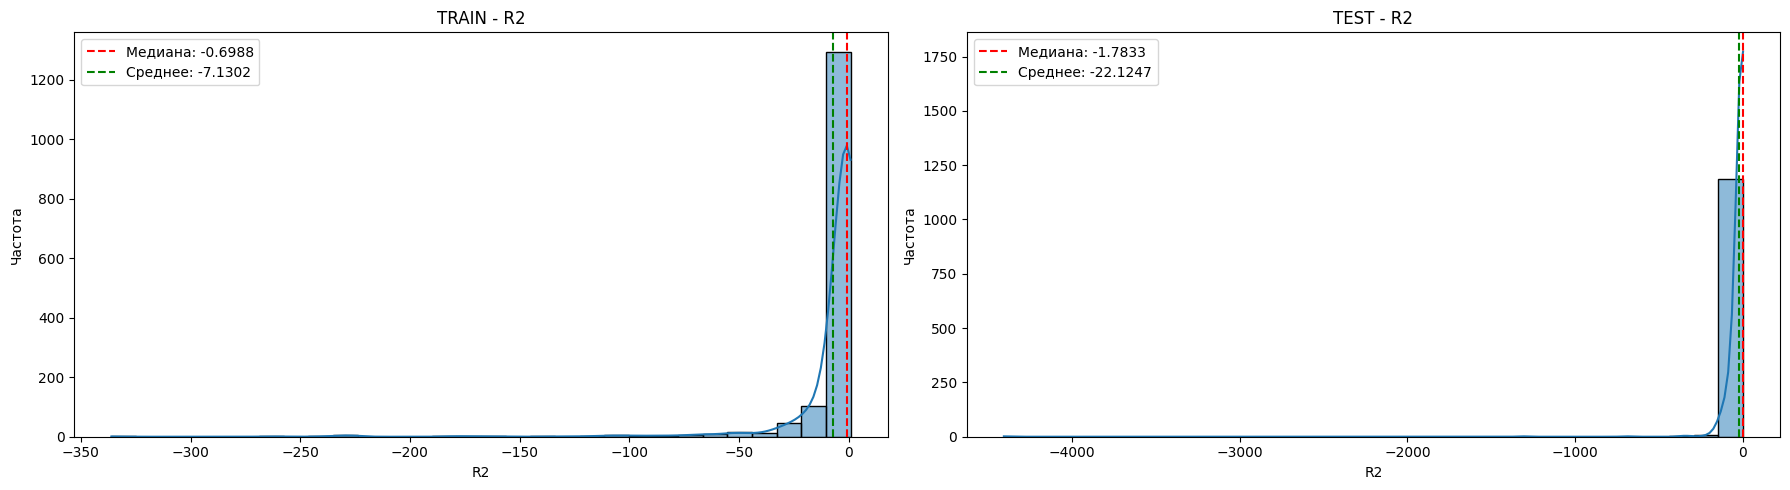

In [8]:
overall_df = results.get_overall_metrics_df()
panel_df = results.get_panel_metrics_df()


plot_overall_metrics_comparison(results)

plot_panel_metrics_distributions(
    results=results,
    metrics_to_plot=["mape", "rmse", "mae", "r2"],
)

In [9]:
plot_best_predictions(
    results=results,
    n_best=5,
    metric="rmse",
    split_name="test",
)

In [10]:
plot_worst_predictions(
    results=results,
    n_worst=5,
    metric="rmse",
    split_name="test",
)

In [11]:
feature_importance = catboost_model.get_feature_importance()
feature_names = regression_splits.train.drop(
    columns=[settings.columns.main_target, settings.columns.id, settings.columns.date]
).columns

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": feature_importance,
    }
).sort_values("importance", ascending=False)

importance_df

,feature,importance
0,sales_lag_1,31.942211
5,sales_ema_2,13.795921
6,sales_ema_3,11.485776
3,sales_ma_2,7.774663
16,panel_id,6.771180
1,sales_lag_2,5.874703
7,sales_diff_1,4.924634
9,panel_mean,4.268037
2,sales_lag_3,3.577606
4,sales_ma_3,2.359274
